<a href="https://colab.research.google.com/github/GORUP-3-AIR/-code/blob/main/%E5%8F%B0%E7%81%A32023-2024%E7%96%BE%E7%97%85%E8%AE%8A%E5%8C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!apt-get update
!apt-get install -y fonts-noto-cjk


Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly insta

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.font_manager as fm
import matplotlib as mpl

# ===============================
# 中文字型（穩定指定路徑）
# ===============================
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False


In [12]:
url = "https://raw.githubusercontent.com/g0v/twgeojson/master/json/twCounty2010.geo.json"
tw = gpd.read_file(url)

# 統一「台 → 臺」
tw["COUNTYNAME"] = tw["COUNTYNAME"].str.replace("台", "臺")


In [18]:
df23 = pd.read_csv(
    "/content/drive/MyDrive/merged_air_cdc_auri_ili_opna_wea_pop_2023_01_2023_12.csv"
)

df24 = pd.read_csv(
    "/content/drive/MyDrive/merged_air_cdc_auri_ili_opna_wea_pop_2024_01_2024_12.csv"
)


In [19]:
def normalize(name):
    name = name.replace("台", "臺")
    if "桃園" in name:
        return "桃園縣"   # 2010 地圖仍是桃園縣
    return name

df23["county"] = df23["county"].apply(normalize)
df24["county"] = df24["county"].apply(normalize)


In [20]:
diseases = {
    "auri": ("auri_visits", "AURI 上呼吸道感染"),
    "ili":  ("ili_visits",  "ILI 類流感"),
    "opna": ("opna_visits", "OPNA 肺炎")
}

In [22]:
def plot_disease(d_code, visits_col, display_name):

    # 每十萬人口就診率
    df23[f"{d_code}_rate"] = df23[visits_col] / df23["pop_cnt"] * 100000
    df24[f"{d_code}_rate"] = df24[visits_col] / df24["pop_cnt"] * 100000

    # 合併地圖
    g23 = tw.merge(df23, left_on="COUNTYNAME", right_on="county", how="left")
    g24 = tw.merge(df24, left_on="COUNTYNAME", right_on="county", how="left")

    # 統一色階
    vmin = min(g23[f"{d_code}_rate"].min(), g24[f"{d_code}_rate"].min())
    vmax = max(g23[f"{d_code}_rate"].max(), g24[f"{d_code}_rate"].max())

    cmap = mpl.cm.hot
    norm = mpl.colors.PowerNorm(gamma=0.5, vmin=vmin, vmax=vmax)

    fig, axes = plt.subplots(
        1, 3, figsize=(32, 16),
        gridspec_kw={"width_ratios": [1, 1, 0.05]}
    )

    # 主標題
    fig.suptitle(
        f"2023 vs 2024 台灣 {display_name} — 每十萬人口就診率比較",
        fontsize=42,
        fontproperties=font_prop,
        y=0.97
    )

    def draw(ax, gdf, year):
        gdf.plot(
            column=f"{d_code}_rate",
            cmap=cmap,
            norm=norm,
            linewidth=1.0,
            edgecolor="black",
            ax=ax
        )

        ax.text(
            0.5, 1.00, f"{year} 年",
            fontsize=32,
            ha="center", va="bottom",
            fontproperties=font_prop,
            transform=ax.transAxes
        )

        for _, row in gdf.iterrows():
            if row.geometry is None:
                continue
            x, y = row.geometry.centroid.x, row.geometry.centroid.y
            ax.text(
                x, y, row["COUNTYNAME"],
                fontsize=14,
                ha="center", va="center",
                fontproperties=font_prop
            )

        ax.set_axis_off()

    draw(axes[0], g23, 2023)
    draw(axes[1], g24, 2024)

    cb = mpl.colorbar.ColorbarBase(
        axes[2], cmap=cmap, norm=norm, orientation="vertical"
    )
    cb.set_label("每十萬人口就診率", fontsize=20, fontproperties=font_prop)

    plt.subplots_adjust(top=0.90)
    plt.show()


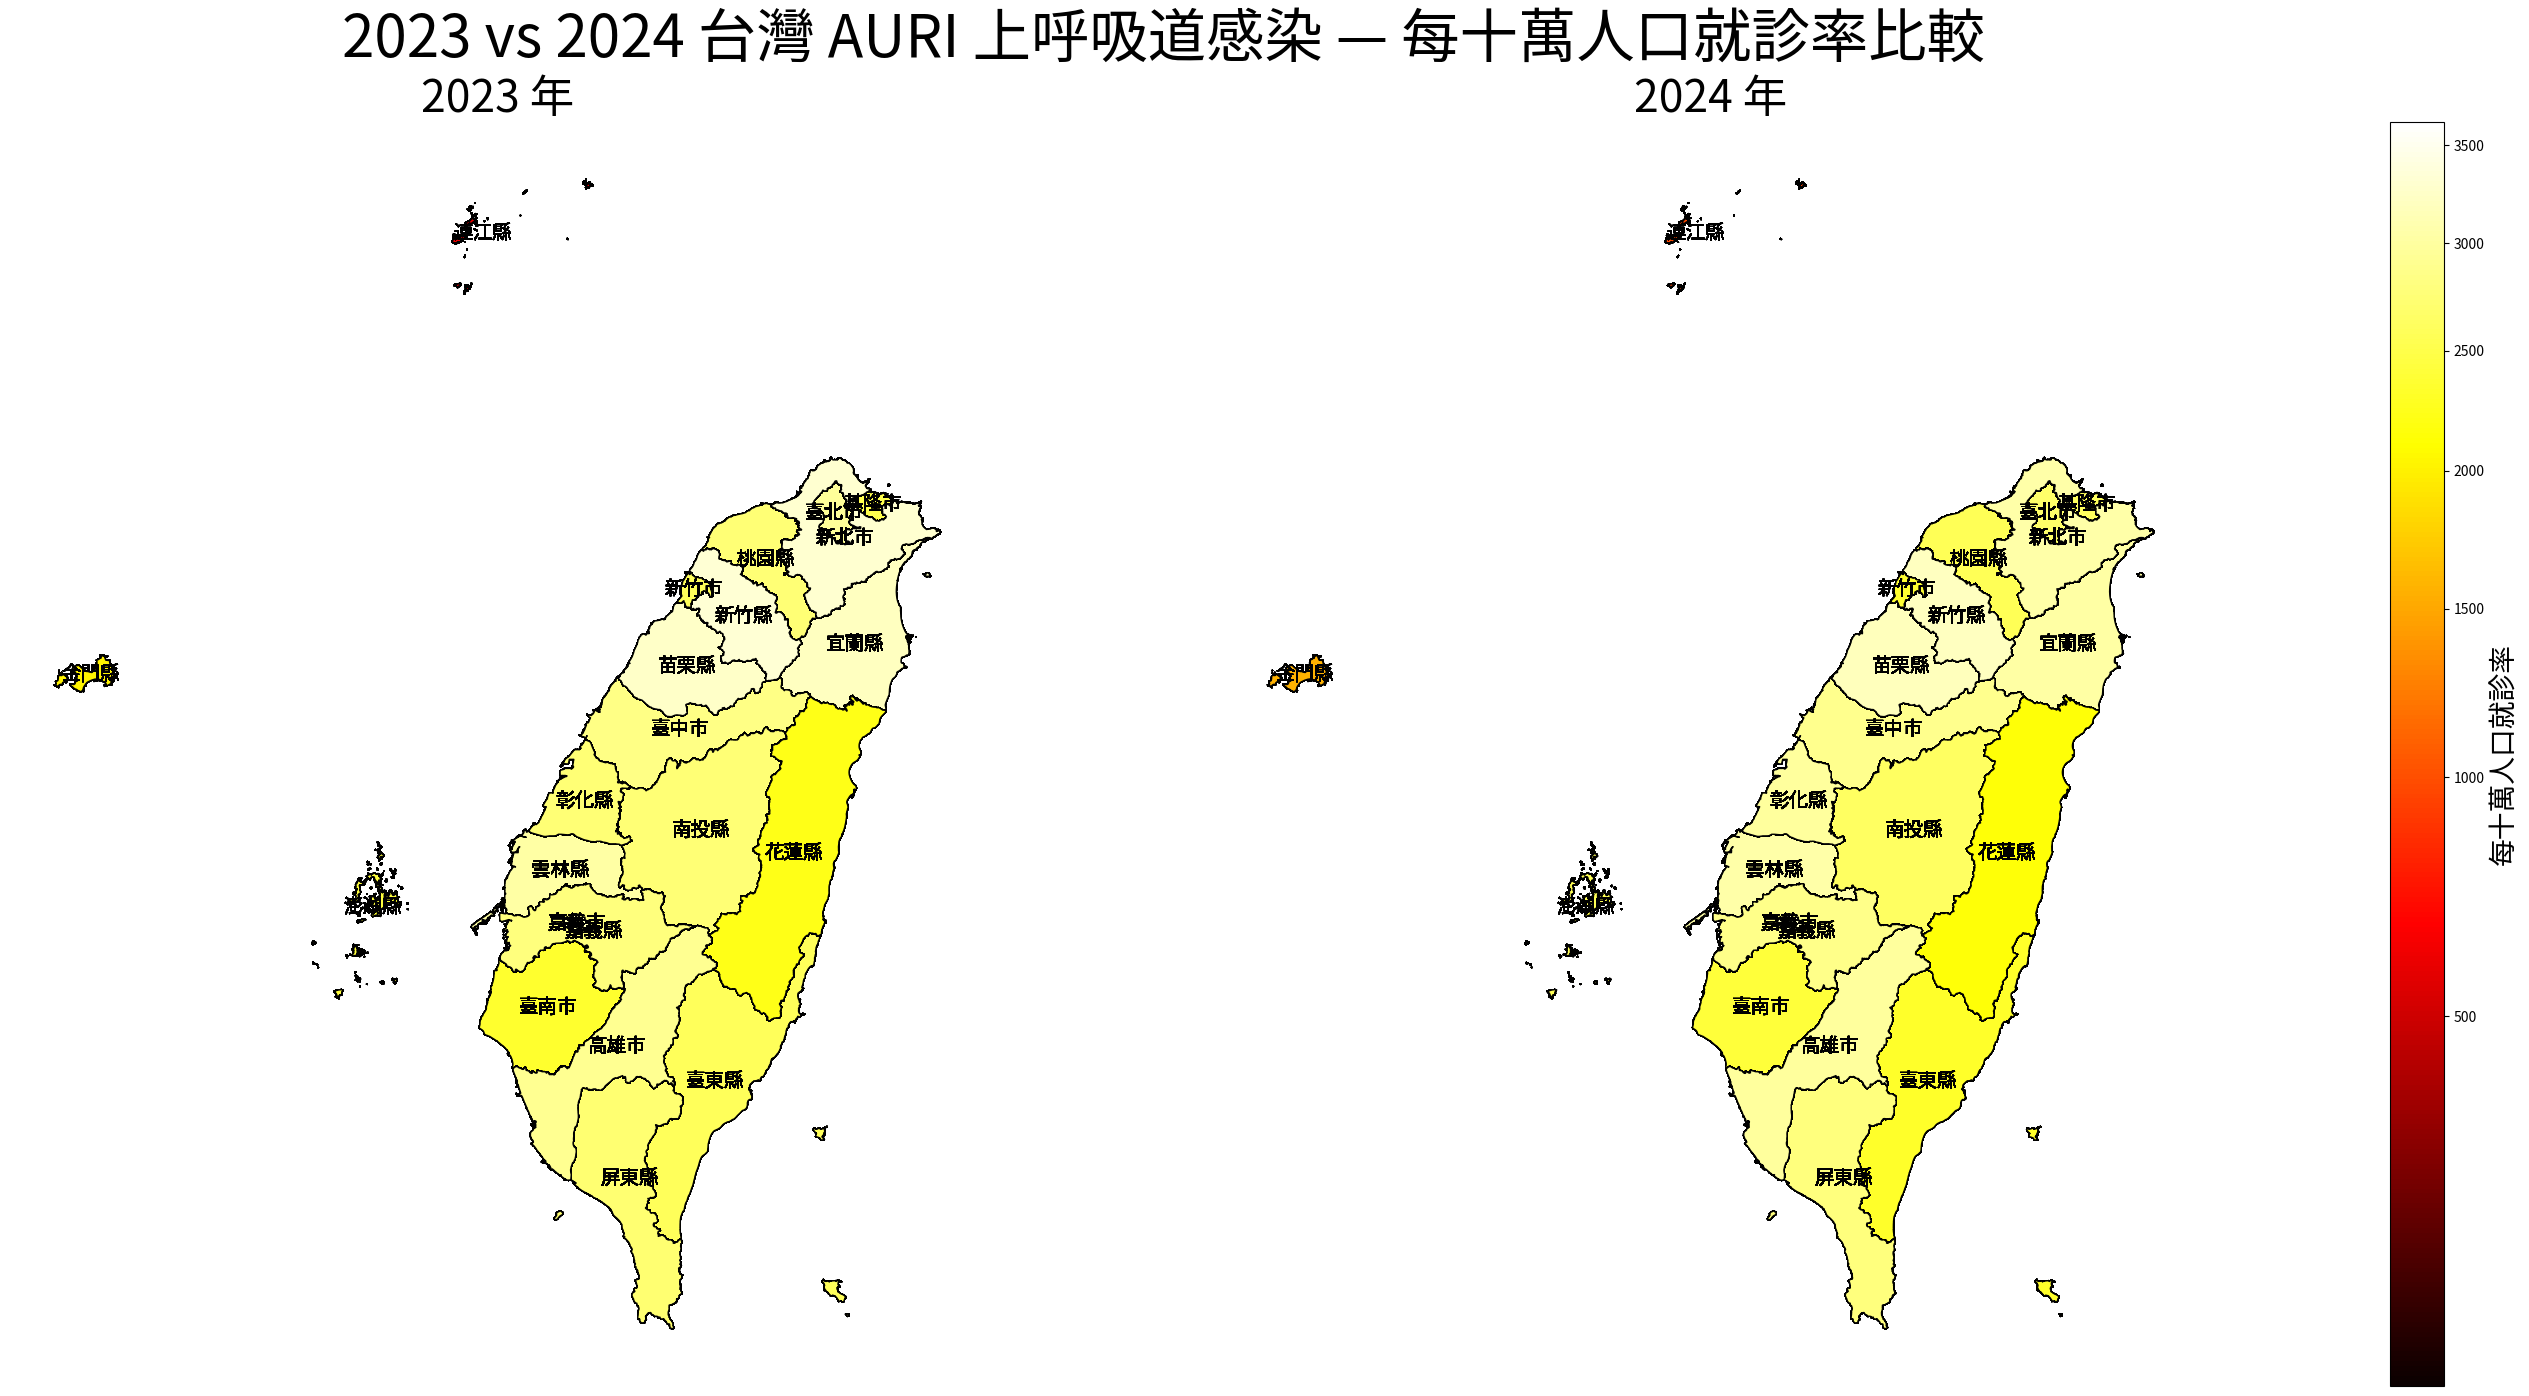

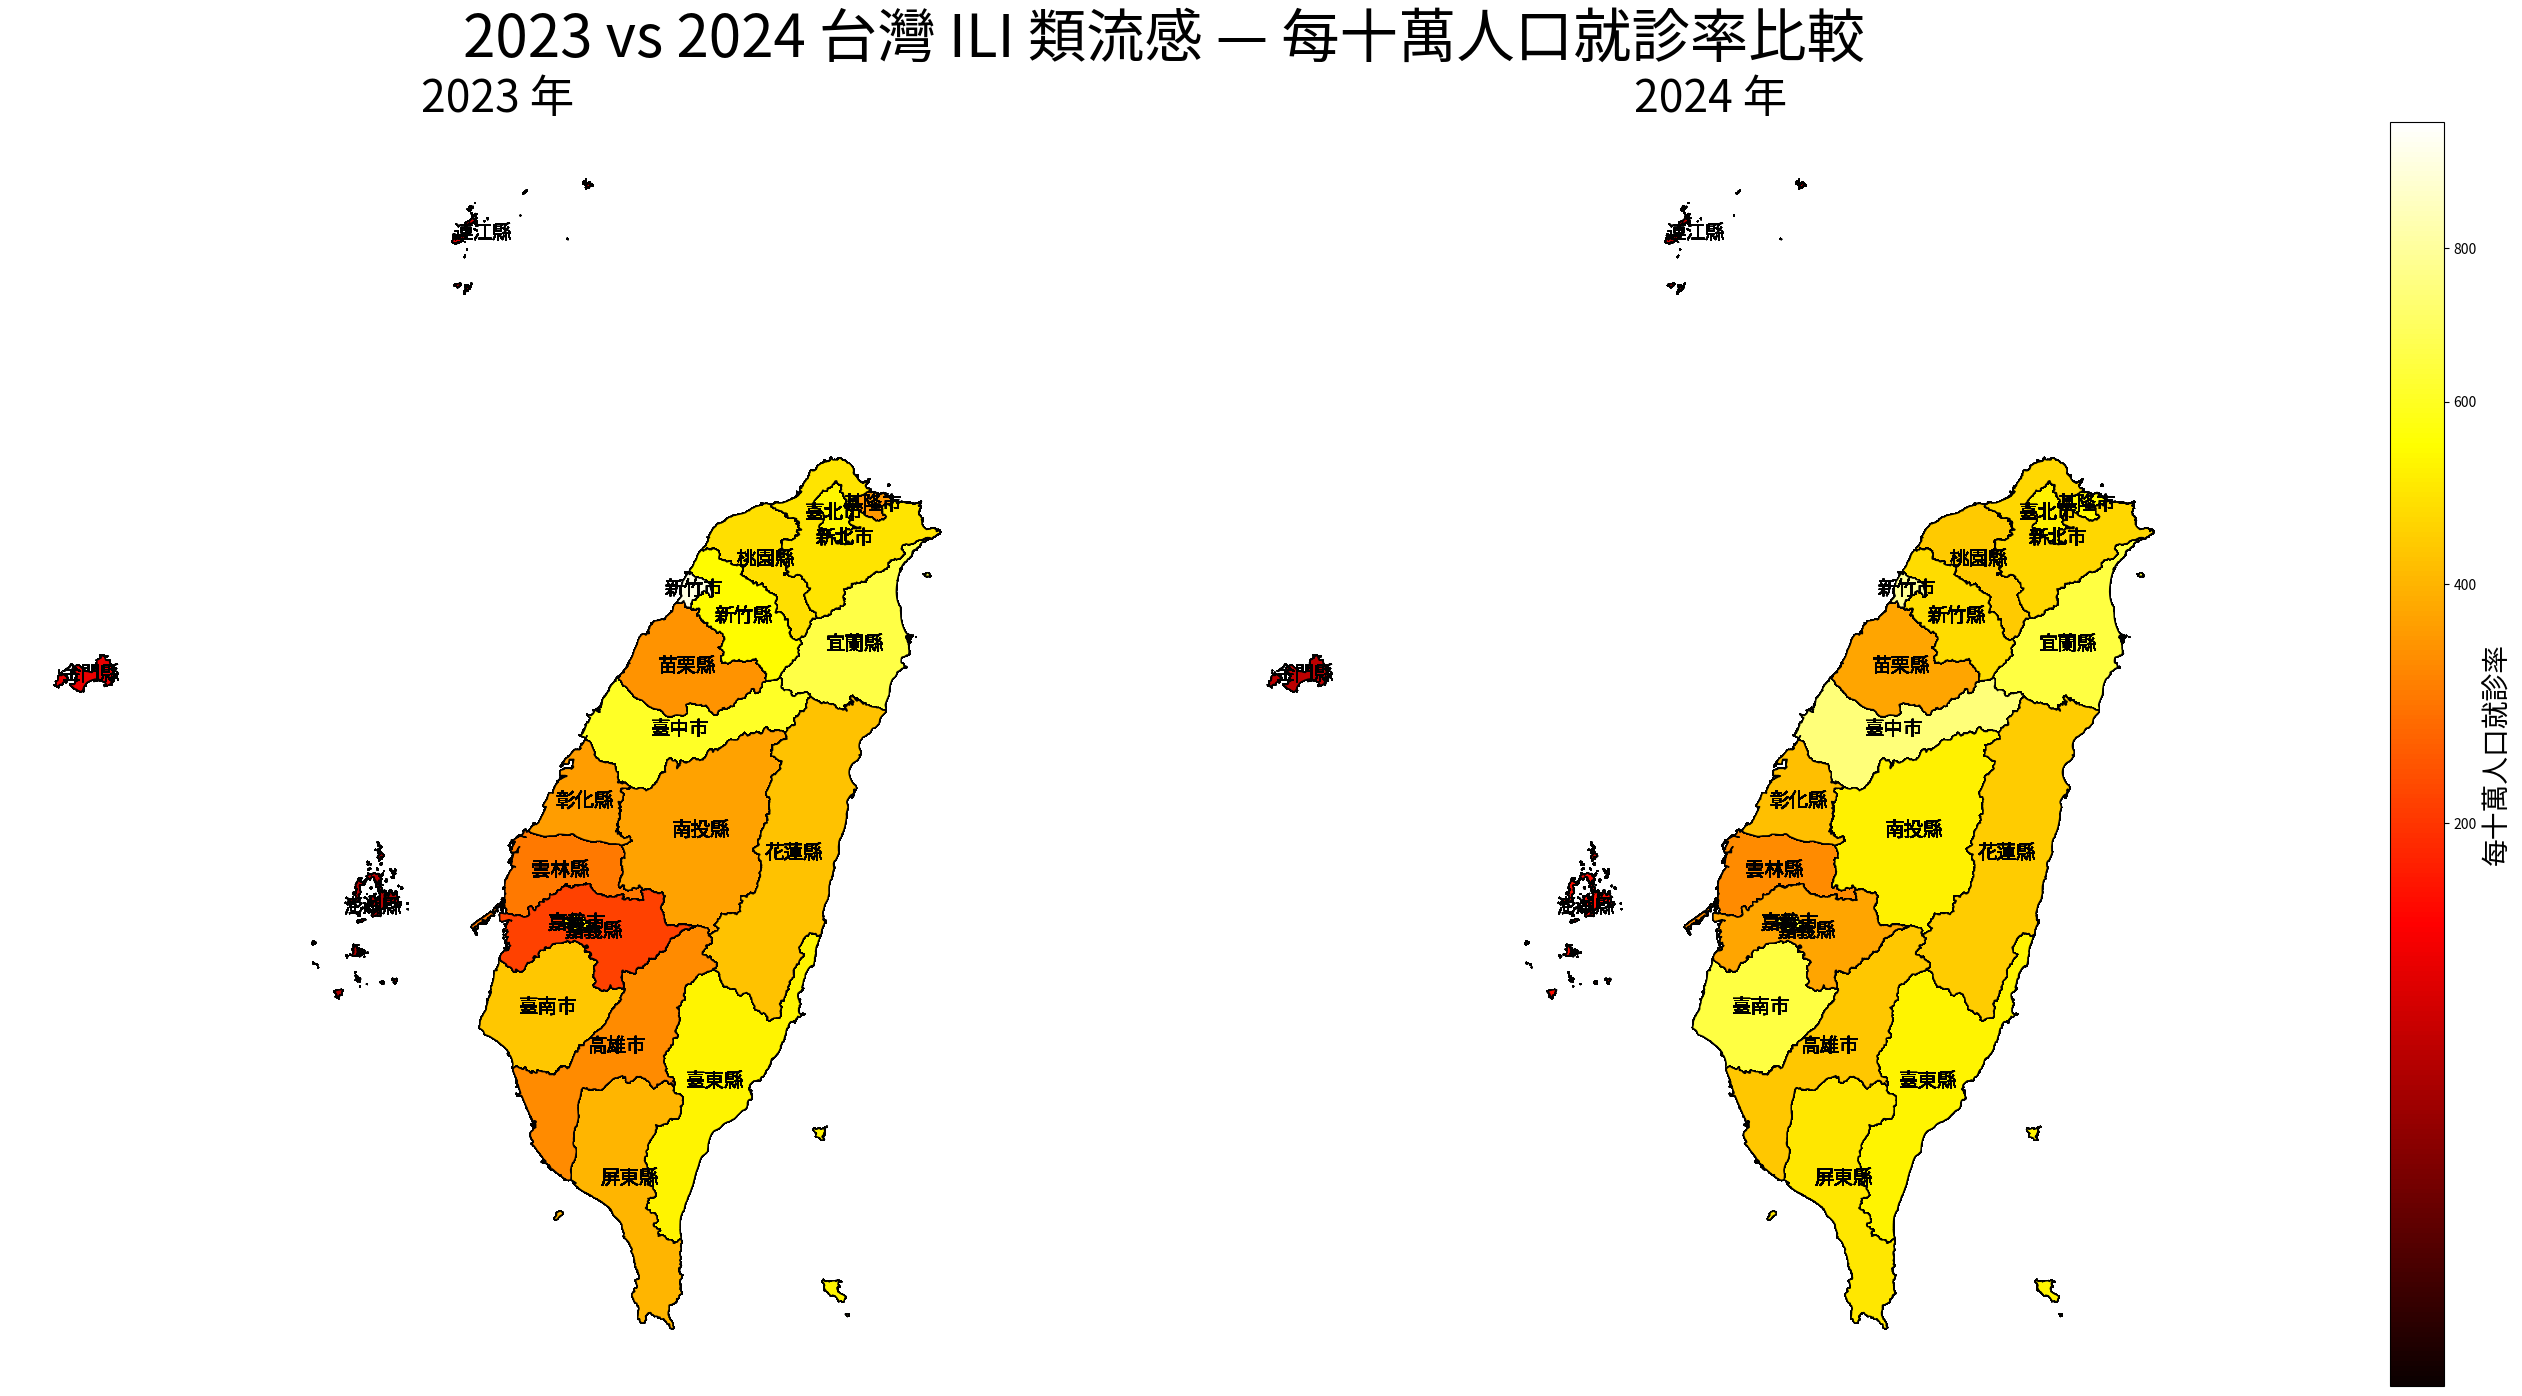

In [ ]:
for d_code, (visits_col, display_name) in diseases.items():
    plot_disease(d_code, visits_col, display_name)
